In [ ]:
%pip install py7zr

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Here is train
Here is test


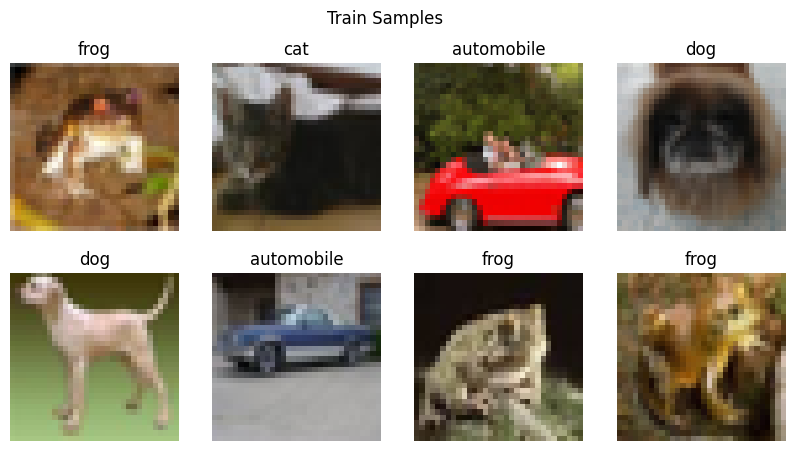

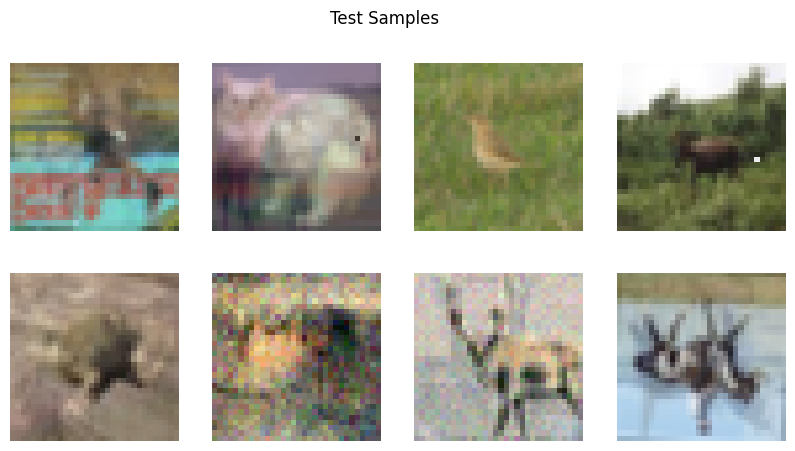

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import csv

def extract_7z(file_path, out_dir):
    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
        print(f"Extracting {file_path} ...")
        os.system(f"7z x {file_path} -o{out_dir} -y")
        print(f"Extracted into {out_dir}")
    else:
        print(f"Here is {out_dir}")

extract_7z("train.7z", "train")
extract_7z("test.7z", "test")


def load_labels(csv_path):
    labels = {}
    with open(csv_path, "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            labels[row[0]] = row[1]
    return labels

train_labels = load_labels("trainLabels.csv")

def load_dataset(img_dir, labels_dict=None, max_samples=16):
    samples = []
    for i, fname in enumerate(sorted(os.listdir(img_dir))):
        if fname.endswith(".png"):
            img_path = os.path.join(img_dir, fname)
            img = plt.imread(img_path)
            if img.dtype == np.uint8:
                img = img.astype(np.float32) / 255.0
            label = labels_dict[fname.split(".")[0]] if labels_dict else None
            samples.append((img, label))
        if len(samples) >= max_samples:
            break
    return samples

train_samples = load_dataset("train", train_labels, max_samples=8)
test_samples = load_dataset("test", None, max_samples=8)


def show_samples(samples, title="Samples"):
    plt.figure(figsize=(10, 5))
    for i, (img, label) in enumerate(samples):
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
        if label:
            plt.title(label)
    plt.suptitle(title)
    plt.show()

show_samples(train_samples, title="Train Samples")
show_samples(test_samples, title="Test Samples")


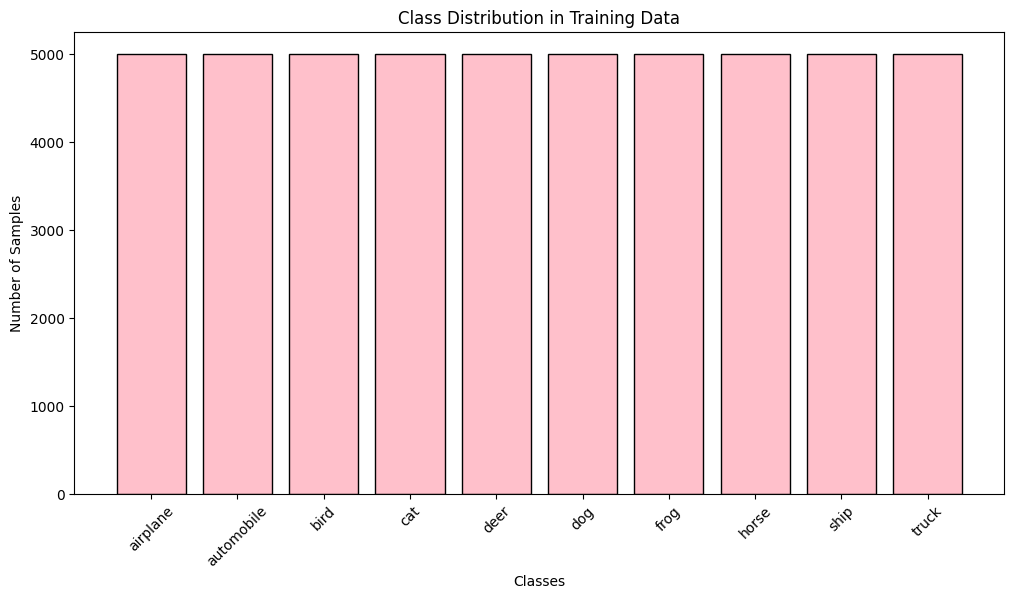

In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

def load_labels(csv_path):
    labels = {}
    with open(csv_path, "r") as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            labels[row[0]] = row[1]
    return labels

train_labels = load_labels("trainLabels.csv")


classes = list(set(train_labels.values()))
classes.sort()

counts = {cls: 0 for cls in classes}
for lbl in train_labels.values():
    counts[lbl] += 1

plt.figure(figsize=(12, 6))
plt.bar(counts.keys(), counts.values(), color="pink", edgecolor="black")
plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Data")
plt.show()


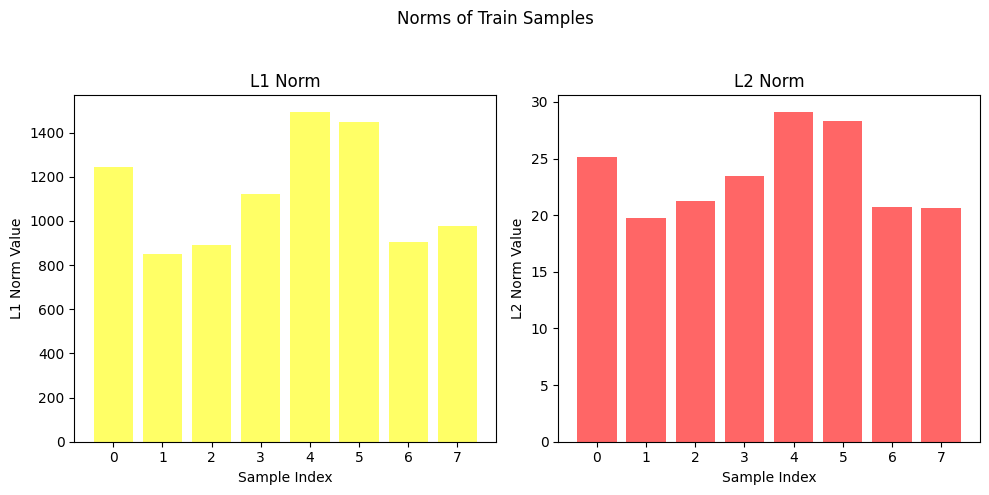

In [ ]:
def show_norms(samples, title="Norms of Samples"):
    l1_norms = []
    l2_norms = []

    for img, _ in samples:
        img_flat = img.flatten()
        l1_norm = np.sum(np.abs(img_flat))
        l2_norm = np.sqrt(np.sum(img_flat ** 2))
        l1_norms.append(l1_norm)
        l2_norms.append(l2_norm)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(l1_norms)), l1_norms, color='yellow', alpha=0.6)
    plt.title("L1 Norm")
    plt.xlabel("Sample Index")
    plt.ylabel("L1 Norm Value")

    plt.subplot(1, 2, 2)
    plt.bar(range(len(l2_norms)), l2_norms, color='red', alpha=0.6)
    plt.title("L2 Norm")
    plt.xlabel("Sample Index")
    plt.ylabel("L2 Norm Value")

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_norms(train_samples, title="Norms of Train Samples")

In [ ]:
import numpy as np

X = np.array([sample[0] for sample in train_samples])

label_names = sorted(list(set([sample[1] for sample in train_samples])))
label_to_idx = {name: idx for idx, name in enumerate(label_names)}
y = np.array([label_to_idx[sample[1]] for sample in train_samples])
y_one_hot = np.eye(len(label_names))[y]

def center_crop(img):
    h, w = img.shape[:2]
    target_size = 64
    start_h = max(0, (h - target_size) // 2)
    start_w = max(0, (w - target_size) // 2)
    end_h = min(h, start_h + target_size)
    end_w = min(w, start_w + target_size)
    cropped_img = img[start_h:end_h, start_w:end_w]

    if cropped_img.shape[0] < 64 or cropped_img.shape[1] < 64:
        padded_img = np.zeros((64, 64, 3), dtype=np.float32)
        padded_img[:cropped_img.shape[0], :cropped_img.shape[1]] = cropped_img
        cropped_img = padded_img
    return cropped_img

X_cropped = np.array([center_crop(img) for img in X])
X_flat = X_cropped.reshape(len(X_cropped), 64 * 64 * 3)

def initialize_weights(input_dim, hidden1_dim, hidden2_dim, output_dim):
    np.random.seed(42)
    W1 = np.random.randn(input_dim, hidden1_dim) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((1, hidden1_dim))
    W2 = np.random.randn(hidden1_dim, hidden2_dim) * np.sqrt(2.0 / hidden1_dim)
    b2 = np.zeros((1, hidden2_dim))
    W3 = np.random.randn(hidden2_dim, output_dim) * np.sqrt(2.0 / hidden2_dim)
    b3 = np.zeros((1, output_dim))
    return W1, b1, W2, b2, W3, b3

def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -10, 10)))
def sigmoid_deriv(x): s = sigmoid(x); return s * (1 - s)
def tanh(x): return np.tanh(np.clip(x, -10, 10))
def tanh_deriv(x): return 1 - np.tanh(x) ** 2

def forward_pass(X, W1, b1, W2, b2, W3, b3, activation):
    Z1 = X @ W1 + b1
    A1 = activation(Z1)
    Z2 = A1 @ W2 + b2
    A2 = activation(Z2)
    Z3 = A2 @ W3 + b3
    return Z3, (Z1, A1, Z2, A2)

def backward_pass(X, y, output, cache, W1, W2, W3, activation_deriv):
    Z1, A1, Z2, A2 = cache
    m = X.shape[0]
    dZ3 = 2 * (output - y) / m
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * activation_deriv(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * activation_deriv(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

def train(X, y, activation, activation_deriv, epochs=10, lr=0.01):
    input_dim = X.shape[1]
    hidden1_dim = 128
    hidden2_dim = 64
    output_dim = y.shape[1]
    W1, b1, W2, b2, W3, b3 = initialize_weights(input_dim, hidden1_dim, hidden2_dim, output_dim)
    grad_norms = []
    for epoch in range(epochs):
        output, cache = forward_pass(X, W1, b1, W2, b2, W3, b3, activation)
        loss = np.mean((output - y) ** 2)
        dW1, db1, dW2, db2, dW3, db3 = backward_pass(X, y, output, cache, W1, W2, W3, activation_deriv)
        grad_norm = np.linalg.norm(dW1)
        grad_norms.append(grad_norm)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        W3 -= lr * dW3
        b3 -= lr * db3

        print(f"Epoch {epoch+1}: Learning rate {lr}, Loss {loss:.4f}")

    return grad_norms

activations = [
    ("ReLU", relu, relu_deriv),
    ("Sigmoid", sigmoid, sigmoid_deriv),
    ("Tanh", tanh, tanh_deriv)
]
all_grad_norms = {}

for name, act, act_deriv in activations:
    print(f"\nTraining with {name} activation:")
    grad_norms = train(X_flat, y_one_hot, act, act_deriv)
    all_grad_norms[name] = grad_norms


print("\nComments on the Gradients:")
print("- ReLU: Gradients may explode initially due to unbounded outputs, potentially leading to instability or drop to zero ('dying ReLU'). Observed norms:", all_grad_norms['ReLU'])
print("- Sigmoid: Gradients tend to vanish as the network saturates, slowing learning. Observed norms:", all_grad_norms['Sigmoid'])
print("- Tanh: Similar to Sigmoid but zero-centered, gradients vanish less severely but still diminish. Observed norms:", all_grad_norms['Tanh'])


Training with ReLU activation:
Epoch 1: Learning rate 0.01, Loss 0.2628
Epoch 2: Learning rate 0.01, Loss 0.6830
Epoch 3: Learning rate 0.01, Loss 0.6813
Epoch 4: Learning rate 0.01, Loss 0.3338
Epoch 5: Learning rate 0.01, Loss 0.2521
Epoch 6: Learning rate 0.01, Loss 0.1454
Epoch 7: Learning rate 0.01, Loss 0.1258
Epoch 8: Learning rate 0.01, Loss 0.1129
Epoch 9: Learning rate 0.01, Loss 0.1041
Epoch 10: Learning rate 0.01, Loss 0.1114

Training with Sigmoid activation:
Epoch 1: Learning rate 0.01, Loss 0.3225
Epoch 2: Learning rate 0.01, Loss 0.2013
Epoch 3: Learning rate 0.01, Loss 0.1803
Epoch 4: Learning rate 0.01, Loss 0.1752
Epoch 5: Learning rate 0.01, Loss 0.1730
Epoch 6: Learning rate 0.01, Loss 0.1712
Epoch 7: Learning rate 0.01, Loss 0.1696
Epoch 8: Learning rate 0.01, Loss 0.1680
Epoch 9: Learning rate 0.01, Loss 0.1664
Epoch 10: Learning rate 0.01, Loss 0.1649

Training with Tanh activation:
Epoch 1: Learning rate 0.01, Loss 0.5776
Epoch 2: Learning rate 0.01, Loss 8.74

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def extract_7z(file_path, out_dir):
    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
        print(f"Extracting {file_path} ...")
        os.system(f"7z x {file_path} -o{out_dir} -y")
        print(f"Extracted into {out_dir}")
    else:
        print(f"Here is {out_dir}")

extract_7z("train.7z", "train")
extract_7z("test.7z", "test")

def load_labels(csv_path):
    labels = {}
    with open(csv_path, "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            labels[row[0]] = row[1]
    return labels

train_labels = load_labels("trainLabels.csv")

Here is train
Here is test


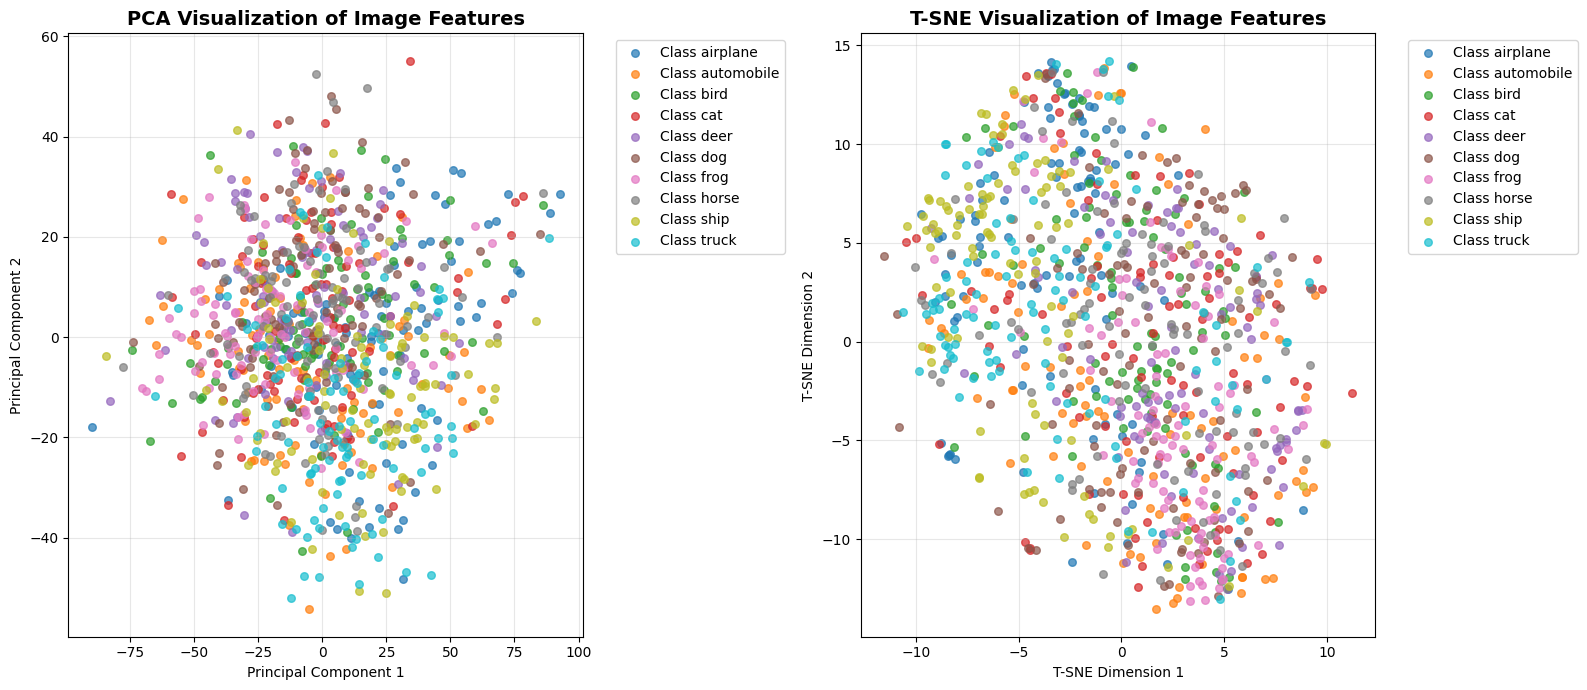


PCA Explained Variance Ratio: [0.27900222 0.11091443]
Total Variance Explained by first 2 PCs: 0.390


In [ ]:
def load_dataset(img_dir, labels_dict=None, max_samples_per_class=100):
    samples = []
    class_counts = {}

    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith(".png"):
            img_path = os.path.join(img_dir, fname)
            img = plt.imread(img_path)
            if img.dtype == np.uint8:
                img = img.astype(np.float32) / 255.0

            label = labels_dict[fname.split(".")[0]] if labels_dict else None

            if label is not None:
                if label not in class_counts:
                    class_counts[label] = 0

                if class_counts[label] < max_samples_per_class:
                    samples.append((img, label))
                    class_counts[label] += 1


            if len(samples) >= max_samples_per_class * 10:  # 10 classes
                break
    return samples

train_samples = load_dataset("train", train_labels, max_samples_per_class=100)

X = np.array([sample[0] for sample in train_samples])
y_labels = np.array([sample[1] for sample in train_samples])

label_names = sorted(list(set(y_labels)))
label_to_idx = {name: idx for idx, name in enumerate(label_names)}
y = np.array([label_to_idx[label] for label in y_labels])

def center_crop(img):
    h, w = img.shape[:2]
    target_size = 64
    start_h = max(0, (h - target_size) // 2)
    start_w = max(0, (w - target_size) // 2)
    end_h = min(h, start_h + target_size)
    end_w = min(w, start_w + target_size)
    cropped_img = img[start_h:end_h, start_w:end_w]

    if cropped_img.shape[0] < 64 or cropped_img.shape[1] < 64:
        padded_img = np.zeros((64, 64, 3), dtype=np.float32)
        padded_img[:cropped_img.shape[0], :cropped_img.shape[1]] = cropped_img
        cropped_img = padded_img
    return cropped_img

X_cropped = np.array([center_crop(img) for img in X])
X_flat = X_cropped.reshape(len(X_cropped), 64 * 64 * 3)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

perplexity = min(30, len(X_scaled) // 10)
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = np.unique(y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = y == label
    ax1.scatter(pca_result[mask, 0], pca_result[mask, 1],
               c=[colors[i]], label=f'Class {label_names[label]}', alpha=0.7, s=30)
ax1.set_title('PCA Visualization of Image Features', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

for i, label in enumerate(unique_labels):
    mask = y == label
    ax2.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               c=[colors[i]], label=f'Class {label_names[label]}', alpha=0.7, s=30)
ax2.set_title('T-SNE Visualization of Image Features', fontsize=14, fontweight='bold')
ax2.set_xlabel('T-SNE Dimension 1')
ax2.set_ylabel('T-SNE Dimension 2')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained by first 2 PCs: {sum(pca.explained_variance_ratio_):.3f}")




